# La carte thermique des thèmes

Construit à partir de [`THEMATIC_HEATMAP.md`](../THEMATIC_HEATMAP.md) — la spécification de design complète pour ce visuel.

Ce notebook charge les artefacts déjà calculés par [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp) (Phase 5 : `lda_topics.parquet`) et les dates déjà figées par [`hansard-pm-extraction`](https://github.com/RedaAllab/hansard-pm-extraction) (`PHASE0_SCOPING.md`, reprises dans `pm_tenures.parquet` et `event_study.py`), sans ré-exécuter `build_lda_topics.py` ni redéfinir la moindre date à l'œil. Il produit les 4 images de `portfolio/02_topic_heatmap/assets/` :

1. `banner.png`
2. `heatmap_main.png` — la carte thermique 13 thèmes × mois
3. `small_multiples.png` — chaque thème séparément
4. `covid_zoom.png` — les 3 thèmes Covid, zoomés

Prérequis : `hansard-pm-nlp` cloné en dossier frère (`../hansard-pm-nlp`) ou `HANSARD_PM_NLP_DIR` pointant dessus — voir le README racine de ce dépôt.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import topic_heatmap as viz
from hansard_pm_portfolio.viz.common import plot_banner, save

ASSETS_DIR = Path("../portfolio/02_topic_heatmap/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. Bannière README

In [2]:
fig = plot_banner("La carte thermique des thèmes", "hansard-pm-portfolio · projet 02")
save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Charger les thèmes, les fenêtres de crise et les dates de transition

- `lda_topics.parquet` (Phase 5) : 296 documents (PM × séance), K=14 thèmes, les 4 PM (Truss incluse, contrairement à Phase 6).
- La fusion T0+T1 (Ukraine/Russie, quasi-identiques) est reprise telle quelle de `phase5_lda_report.md` — voir `data_access.merge_overlapping_topics()`.
- Les 13 libellés en langage courant (`data_access.TOPIC_LABELS`) sont un travail éditorial nouveau pour ce projet : ni `phase5_lda_report.md` ni le dashboard live n'en proposent (le dashboard n'affiche que des labels algorithmiques du type « T2: hs, project, rail ») — écrits à partir des listes de mots-clés du rapport, traçabilité en commentaire dans `data_access.py`.
- Les fenêtres de crise et les dates de mandat viennent de `data_access.CRISIS_WINDOWS` (porté depuis `event_study.py`) et `load_pm_tenures()` (`data/input/pm_tenures.parquet`) — vérifiées identiques à `PHASE0_SCOPING.md`.

In [3]:
topics = da.load_topic_weights()
tenures = da.load_pm_tenures()
monthly = da.monthly_topic_matrix(topics)
print(f"{len(topics)} documents, {monthly.shape[0]} mois, {monthly.shape[1]} thèmes")
tenures

296 documents, 77 mois, 13 thèmes


,pm_name,pm_party,member_id,tenure_start,tenure_end
0,Boris Johnson,Conservative,1423,2019-07-24,2022-09-06
1,Liz Truss,Conservative,4097,2022-09-06,2022-10-25
2,Rishi Sunak,Conservative,4483,2022-10-25,2024-07-05
3,Keir Starmer,Labour,4514,2024-07-05,2026-07-20


## 2. La carte thermique principale

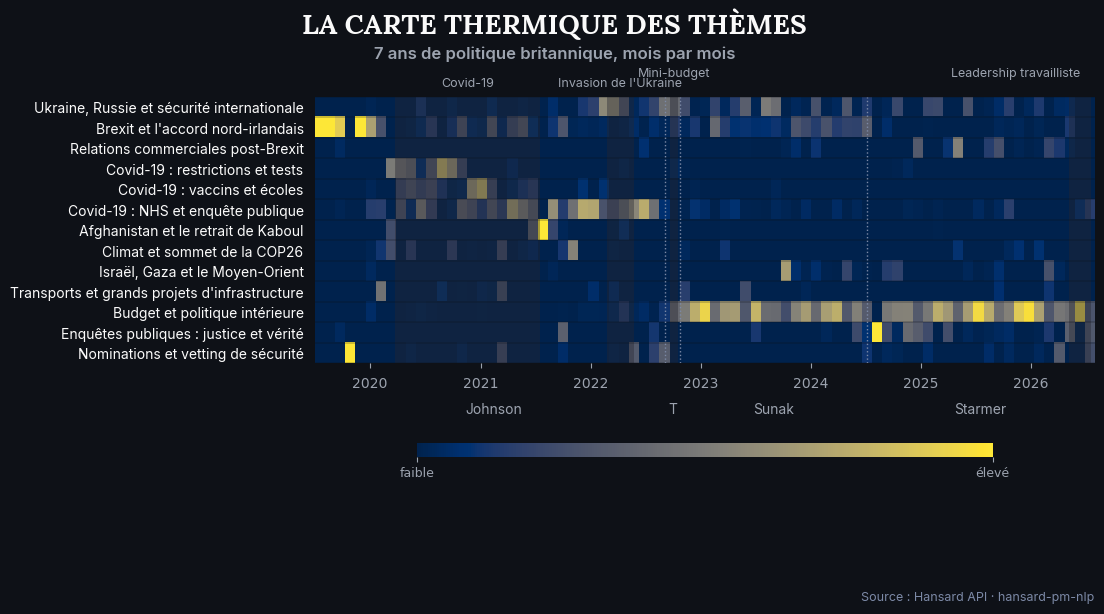

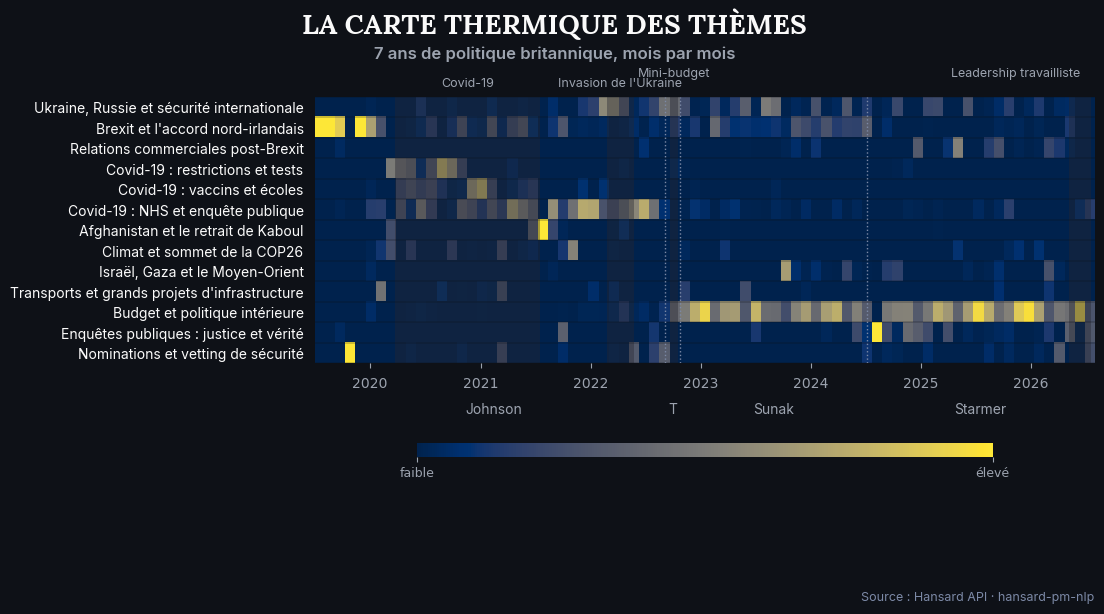

In [4]:
fig = viz.plot_topic_heatmap(monthly, tenures)
save(fig, ASSETS_DIR / "heatmap_main.png")
fig

## 3. Chaque thème séparément

Small multiples plutôt qu'un streamgraph à 13 couleurs superposées — app.py (dashboard live) a déjà testé les deux pour son propre onglet Topics et documenté pourquoi les small multiples l'emportent à cette échelle (légende à 13 couleurs illisible, aire empilée qui masque si un thème monte ou descend). Reprise à l'identique plutôt que retestée.

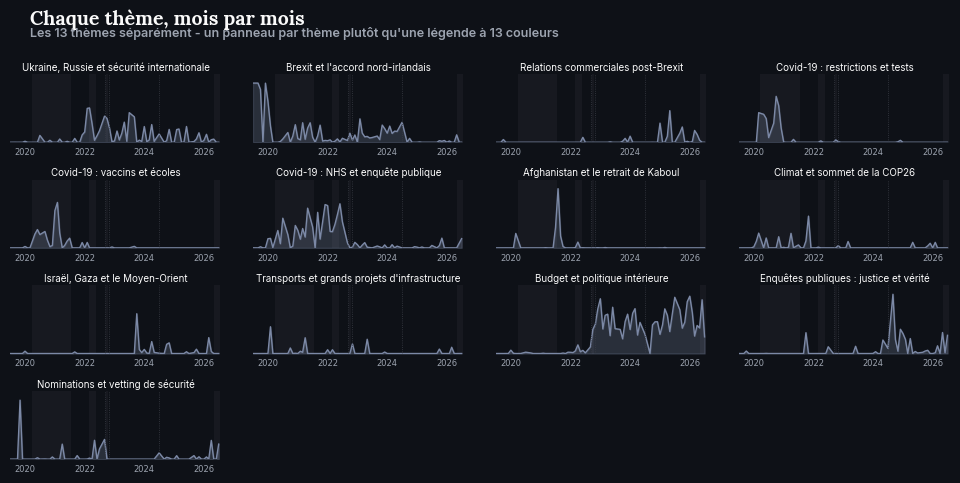

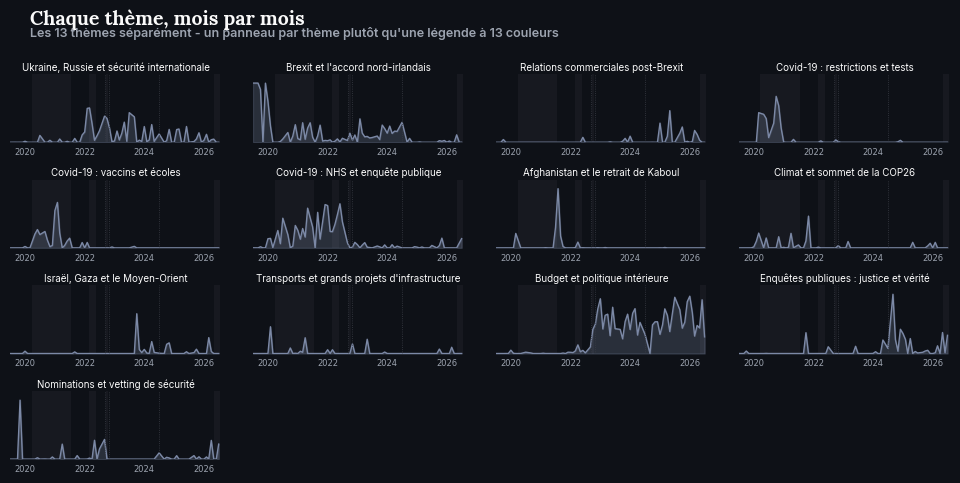

In [5]:
fig = viz.plot_topic_small_multiples(monthly, tenures)
save(fig, ASSETS_DIR / "small_multiples.png")
fig

## 4. Covid-19 : pourquoi 3 thèmes, pas 1

Contrairement à Ukraine/Russie (T0+T1), les 3 thèmes Covid n'ont jamais été fusionnés. Ce n'est pas une lacune : `app.py` (onglet Topics du dashboard live) documente déjà pourquoi - ces 3 thèmes suivent des sous-phases distinctes de la même crise (restrictions/tests, vaccins/écoles, personnel NHS/enquête publique), pas un doublon comme T0/T1.

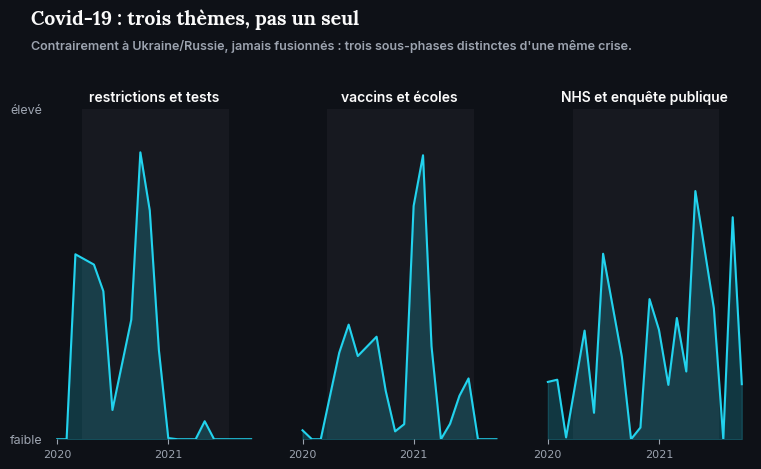

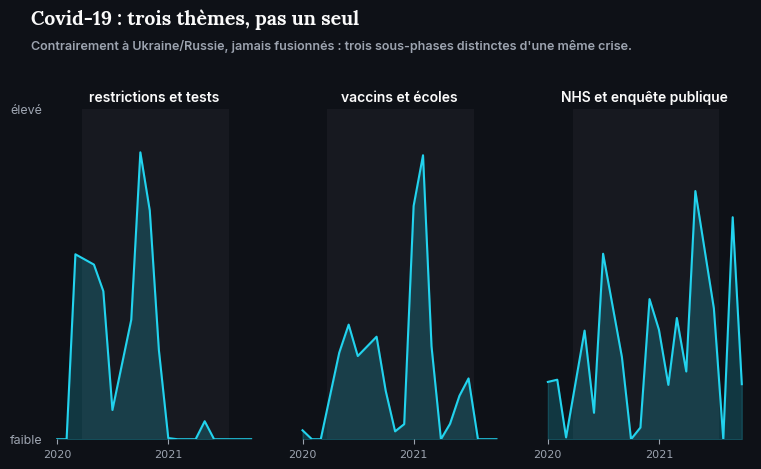

In [6]:
fig = viz.plot_covid_zoom(monthly)
save(fig, ASSETS_DIR / "covid_zoom.png")
fig

## Liens

- Spécification complète : [`THEMATIC_HEATMAP.md`](../THEMATIC_HEATMAP.md)
- Rapport source du modèle LDA : [`phase5_lda_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase5_lda_report.md) (dans `hansard-pm-nlp`)
- Comparaison LDA vs BERTopic : [`phase5_topic_comparison_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase5_topic_comparison_report.md)
- Dashboard interactif : voir le README racine de `hansard-pm-nlp`
- README de ce projet : [`portfolio/02_topic_heatmap/README.md`](../portfolio/02_topic_heatmap/README.md)